# Movie Rating Prediction
### Mini Project — B.Tech CSE (Session 2026-27)

**Goal:** Predict whether a movie is a **"Hit"** (IMDb score ≥ 7) or **"Not a Hit"**, using basic movie details —
budget, genre, runtime, and number of votes.

**Dataset:** IMDb 5000 Movie Dataset (`movie_metadata.csv`) — 5,043 real movies with budget, genre, cast, and rating info.
Place `movie_metadata.csv` in the same folder as this notebook before running.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)


## 1. Load the Data

In [2]:
df = pd.read_csv("movie_metadata.csv")
print("Shape:", df.shape)
df.head()


Shape: (5043, 28)


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


## 2. Keep Only the Columns We Need
To keep things simple, we use just a handful of basic features instead of all 28 columns.

In [3]:
cols = ["budget", "duration", "genres", "num_voted_users", "title_year", "imdb_score"]
df = df[cols]
df.head()


,budget,duration,genres,num_voted_users,title_year,imdb_score
0,237000000.0,178.0,Action|Adventure|Fantasy|Sci-Fi,886204,2009.0,7.9
1,300000000.0,169.0,Action|Adventure|Fantasy,471220,2007.0,7.1
2,245000000.0,148.0,Action|Adventure|Thriller,275868,2015.0,6.8
3,250000000.0,164.0,Action|Thriller,1144337,2012.0,8.5
4,NaN,NaN,Documentary,8,NaN,7.1


## 3. Basic Cleaning

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values 
df = df.dropna()
print("\nShape after dropping missing rows:", df.shape)


Missing values before cleaning:
budget             492
duration            15
genres               0
num_voted_users      0
title_year         108
imdb_score           0
dtype: int64

Shape after dropping missing rows: (4538, 6)


In [5]:
# Genres column has multiple genres separated by '|' e.g. "Action|Adventure|Fantasy"
# For simplicity, keep only the FIRST (primary) genre
df["main_genre"] = df["genres"].apply(lambda x: x.split("|")[0])
df[["genres", "main_genre"]].head()


,genres,main_genre
0,Action|Adventure|Fantasy|Sci-Fi,Action
1,Action|Adventure|Fantasy,Action
2,Action|Adventure|Thriller,Action
3,Action|Thriller,Action
5,Action|Adventure|Sci-Fi,Action


## 4. Create the Target Variable: Hit or Not

hit
0    2991
1    1547
Name: count, dtype: int64


C:\Users\tarun\AppData\Local\Temp\ipykernel_4580\1710150229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="hit", data=df, palette="Set2")


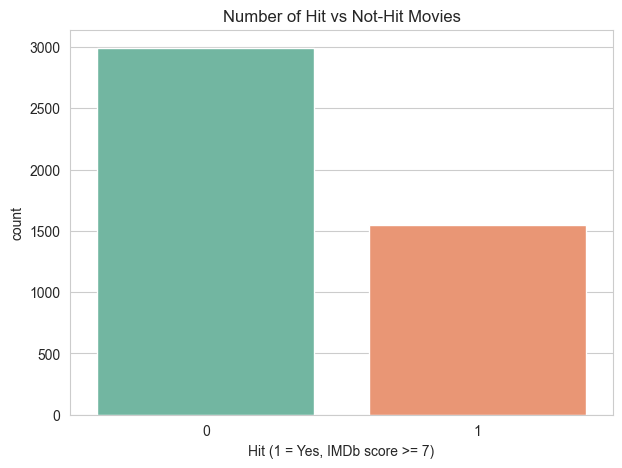

In [6]:
df["hit"] = (df["imdb_score"] >= 7).astype(int)

print(df["hit"].value_counts())
sns.countplot(x="hit", data=df, palette="Set2")
plt.title("Number of Hit vs Not-Hit Movies")
plt.xlabel("Hit (1 = Yes, IMDb score >= 7)")
plt.show()


## 5. Exploratory Data Analysis (EDA)

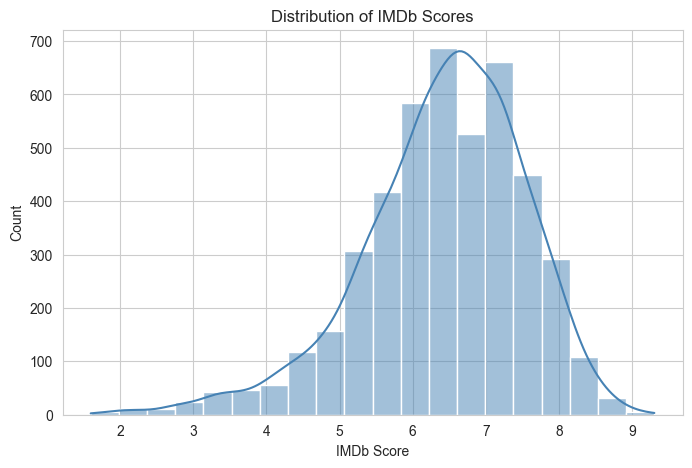

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["imdb_score"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of IMDb Scores")
plt.xlabel("IMDb Score")
plt.show()


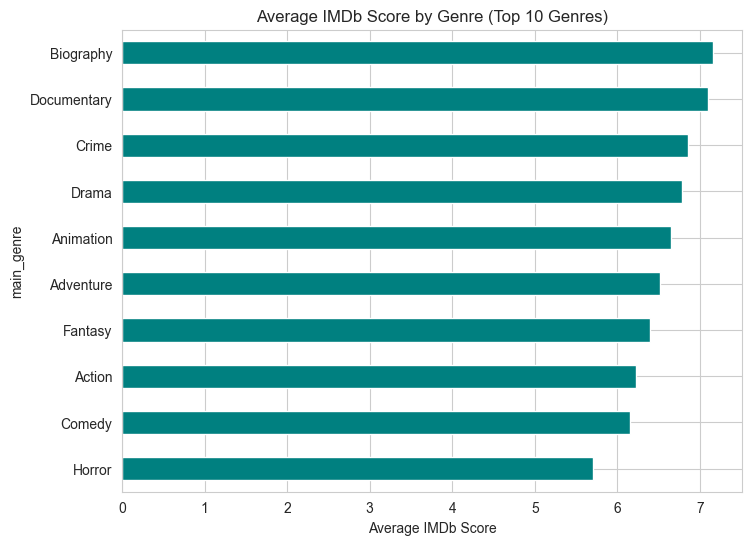

In [8]:
# Top 10 most common genres and their average IMDb score
top_genres = df["main_genre"].value_counts().head(10).index
genre_avg = df[df["main_genre"].isin(top_genres)].groupby("main_genre")["imdb_score"].mean().sort_values()

plt.figure(figsize=(8,6))
genre_avg.plot(kind="barh", color="teal")
plt.title("Average IMDb Score by Genre (Top 10 Genres)")
plt.xlabel("Average IMDb Score")
plt.show()


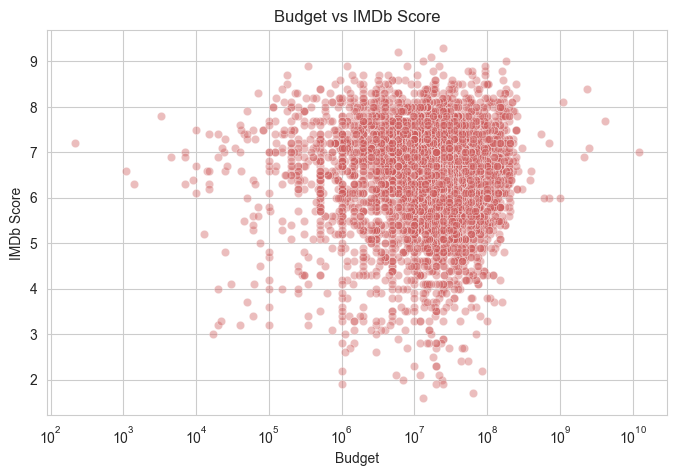

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="budget", y="imdb_score", data=df, alpha=0.4, color="indianred")
plt.title("Budget vs IMDb Score")
plt.xlabel("Budget")
plt.ylabel("IMDb Score")
plt.xscale("log")
plt.show()


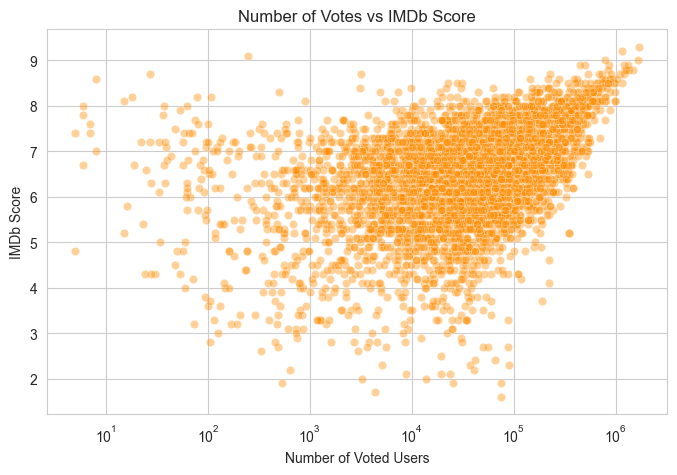

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="num_voted_users", y="imdb_score", data=df, alpha=0.4, color="darkorange")
plt.title("Number of Votes vs IMDb Score")
plt.xlabel("Number of Voted Users")
plt.ylabel("IMDb Score")
plt.xscale("log")
plt.show()


**EDA takeaway:**
Movies with a very high number of votes tend to skew toward higher IMDb scores, and certain genres
(e.g. Documentary, Biography) tend to average higher ratings than others (e.g. Horror).


## 6. Preprocessing for the Model

In [11]:
model_df = df.drop(columns=["genres", "imdb_score"])  # drop original genres text col and raw score (used to build target)

le = LabelEncoder()
model_df["main_genre"] = le.fit_transform(model_df["main_genre"])

X = model_df.drop(columns=["hit"])
y = model_df["hit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (3630, 5)  Test shape: (908, 5)


## 7. Train the Model
A single Decision Tree classifier — simple and easy to explain in a viva.

In [12]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7654185022026432


              precision    recall  f1-score   support

     Not Hit       0.79      0.87      0.83       598
         Hit       0.69      0.56      0.62       310

    accuracy                           0.77       908
   macro avg       0.74      0.72      0.73       908
weighted avg       0.76      0.77      0.76       908



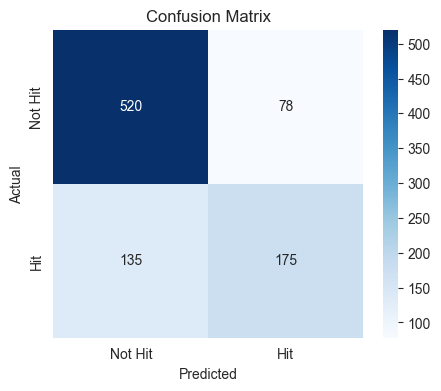

In [13]:
print(classification_report(y_test, y_pred, target_names=["Not Hit", "Hit"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Hit", "Hit"], yticklabels=["Not Hit", "Hit"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


## 8. Which Features Matter Most?

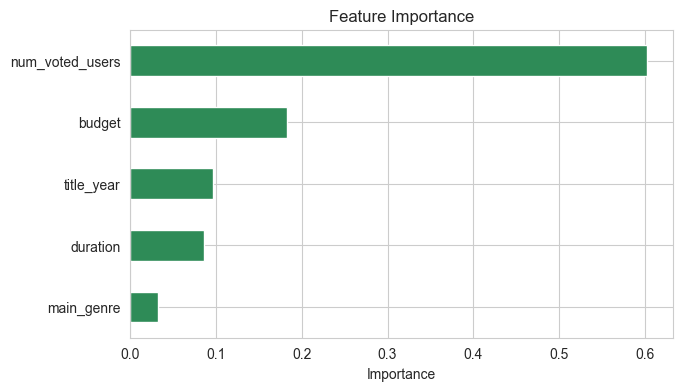

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
importances.plot(kind="barh", color="seagreen")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()


## 9. Summary

- Used a single, clean dataset (`movie_metadata.csv`) with just 5 basic input features.
- Defined a simple target: Hit (IMDb score ≥ 7) vs Not Hit.
- Trained one Decision Tree model and evaluated it with accuracy, a classification report, and a confusion matrix.
- Checked which features matter most for the prediction.

